# Peptide-MHC Binding Prediction
***Artificial Intelligence For Science - 4960*** <br>
***Task One - Traditional AI: Linear Regression, Random Forests, XGBoost*** <br>
***By: Swaroop Sridhar*** <br>



- Import the necessary libraries:
  - `numpy` and `pandas` for data manipulation
  - `matplotlib.pyplot` and `seaborn` for data visualization
  - `PeptideMHC` from TDC for loading the dataset
  - Various `sklearn` modules for machine learning tasks

- We then load the MHC1_IEDB-IMGT_Nielsen dataset using TDC's `PeptideMHC` class.
- We prepare our features (X) and target (y) from the loaded data.
  - X contains 'peptide' and 'mhc' sequences
  - y contains the binding affinity values

With this, we now have the setup which provides us the raw data necessary for out data training.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tdc.multi_pred import PeptideMHC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

#load the data.
data = PeptideMHC(name='MHC1_IEDB-IMGT_Nielsen')
split = data.get_split()

#prepare the features and target.
X = pd.DataFrame({'peptide': split['train']['Peptide'], 'mhc': split['train']['MHC']})
y = split['train']['Y']

Found local copy...
Loading...
Done!


- Here, we determine the maximum lengths of peptide and MHC sequence to ensure uniform coding.
- In the `encode_sequence` function:
  - we perform one-hot encoding for amino acid sequences.
  - create a binary matrix where each row represents a position in the sequence and the column represents one of the 20 amino acids.
  - This encoding is what the ml models will be able to process.
- This applied to both sequences.
- Can then combine the features into a single array `X_encoded`.
- Then scale our features using `StandardScalar`.

In [3]:
#determine max lengths.
max_peptide_length = X['peptide'].str.len().max()
max_mhc_length = X['mhc'].str.len().max()

#function to encode amino acid sequences.
def encode_sequence(seq, max_length):
    amino_acids = 'ACDEFGHIKLMNPQRSTVWY'
    encoding = np.zeros((max_length, len(amino_acids)))
    for i, aa in enumerate(seq[:max_length]):
        if aa in amino_acids:
            encoding[i, amino_acids.index(aa)] = 1
    return encoding.flatten()

#encode the peptide and MHC sequences.
X['peptide_encoded'] = X['peptide'].apply(lambda x: encode_sequence(x, max_peptide_length))
X['mhc_encoded'] = X['mhc'].apply(lambda x: encode_sequence(x, max_mhc_length))

#combine the encoded features.
X_encoded = np.column_stack((np.vstack(X['peptide_encoded']), np.vstack(X['mhc_encoded'])))

#split the data
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

#scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

- The `train_and_evaluate` function does:
  - streamlines the process of training a model and calculating the performance
  - returns MSE and R2 values.
- We then create 3 different models which:
  - Linear Regression
  - Random Forest
  - XGBoost
- For each, we train it and make predictions on the tests as well as calculate MSE and R2 values.

In [4]:
def train_and_evaluate(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    return mse, r2, y_pred

#Linear Regression
lr_model = LinearRegression()
lr_mse, lr_r2, lr_pred = train_and_evaluate(lr_model, X_train_scaled, X_test_scaled, y_train, y_test)

#Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_mse, rf_r2, rf_pred = train_and_evaluate(rf_model, X_train, X_test, y_train, y_test)

#XGBoost
xgb_model = XGBRegressor(n_estimators=100, random_state=42)
xgb_mse, xgb_r2, xgb_pred = train_and_evaluate(xgb_model, X_train, X_test, y_train, y_test)

# Print results
print("Linear Regression Results:")
print("Mean Squared Error:", lr_mse)
print("R-squared Score:", lr_r2)

print("\nRandom Forest Results:")
print("Mean Squared Error:", rf_mse)
print("R-squared Score:", rf_r2)

print("\nXGBoost Results:")
print("Mean Squared Error:", xgb_mse)
print("R-squared Score:", xgb_r2)

Linear Regression Results:
Mean Squared Error: 8.264391209744873e+21
R-squared Score: -1.0185277604860501e+23

Random Forest Results:
Mean Squared Error: 0.031176032272579642
R-squared Score: 0.6157774538312106

XGBoost Results:
Mean Squared Error: 0.037636145554537405
R-squared Score: 0.5361611270314808


These are scatter plots which visualize the relationship between actual and predicted values for each model.

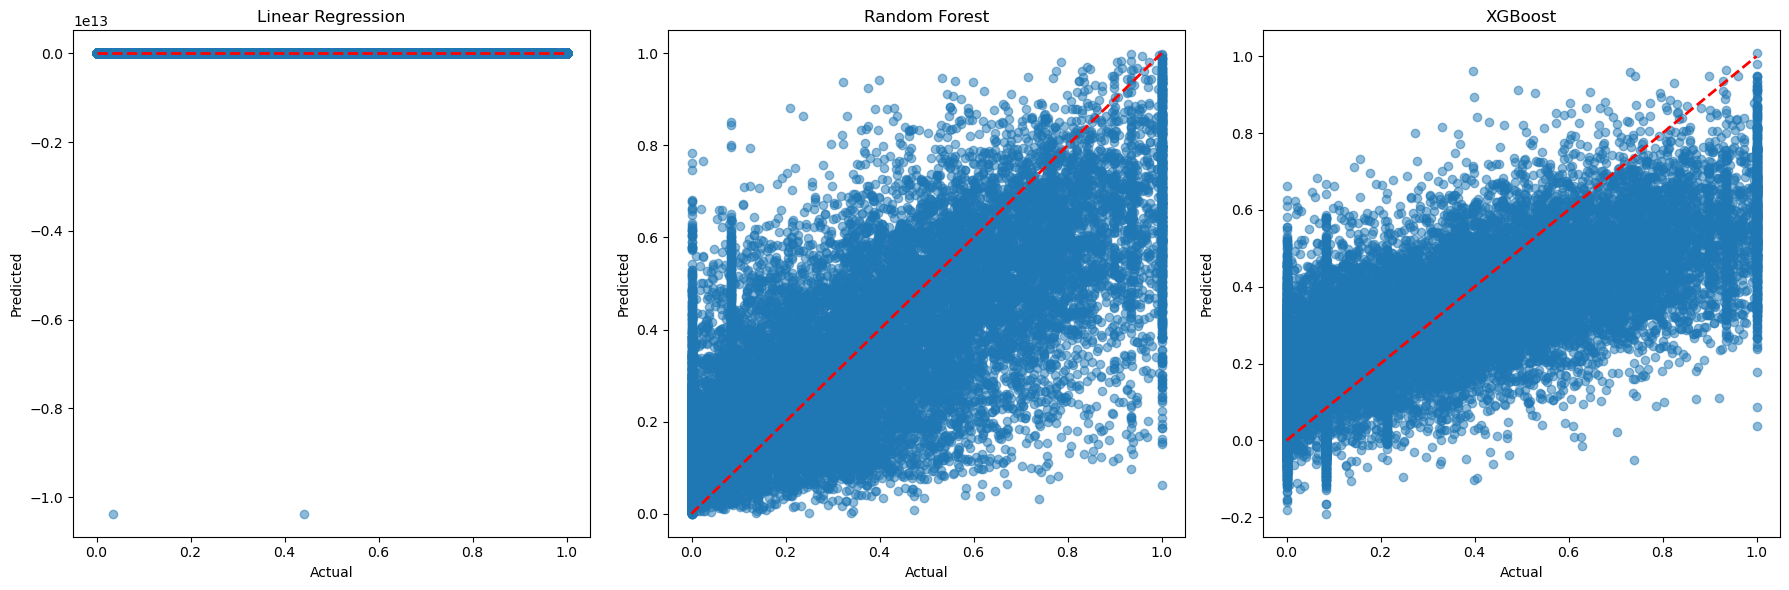

In [5]:
#scatter plots of predicted vs actual values
plt.figure(figsize=(18, 6))

plt.subplot(131)
plt.scatter(y_test, lr_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Linear Regression')

plt.subplot(132)
plt.scatter(y_test, rf_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Random Forest')

plt.subplot(133)
plt.scatter(y_test, xgb_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('XGBoost')

plt.tight_layout()
plt.show()

These are residual plots which are important for assessing quality of regression model.

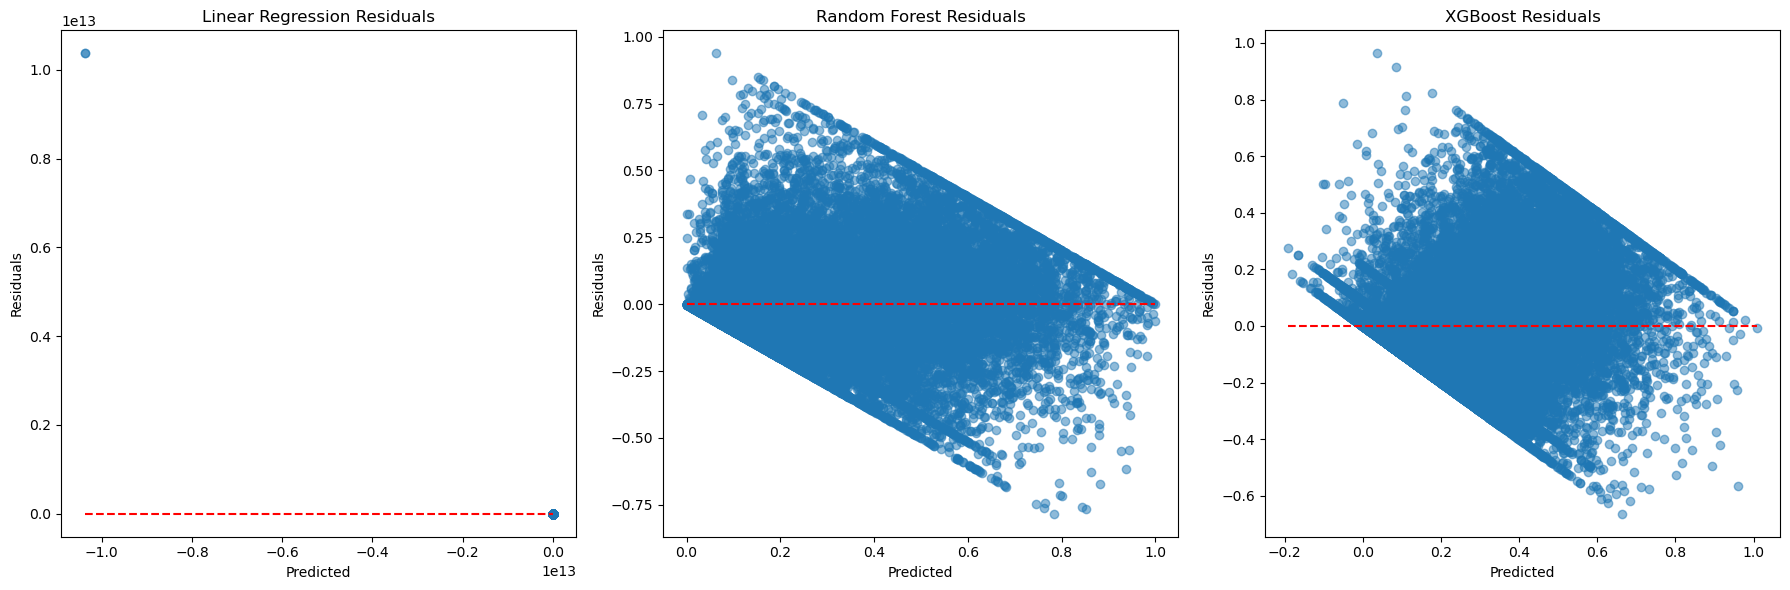

In [6]:
#residual plots
plt.figure(figsize=(18, 6))

plt.subplot(131)
plt.scatter(lr_pred, y_test - lr_pred, alpha=0.5)
plt.hlines(y=0, xmin=lr_pred.min(), xmax=lr_pred.max(), color='r', linestyle='--')
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.title('Linear Regression Residuals')

plt.subplot(132)
plt.scatter(rf_pred, y_test - rf_pred, alpha=0.5)
plt.hlines(y=0, xmin=rf_pred.min(), xmax=rf_pred.max(), color='r', linestyle='--')
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.title('Random Forest Residuals')

plt.subplot(133)
plt.scatter(xgb_pred, y_test - xgb_pred, alpha=0.5)
plt.hlines(y=0, xmin=xgb_pred.min(), xmax=xgb_pred.max(), color='r', linestyle='--')
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.title('XGBoost Residuals')

plt.tight_layout()
plt.show()

These are bar plots which provide a side by side comparison of model performance.

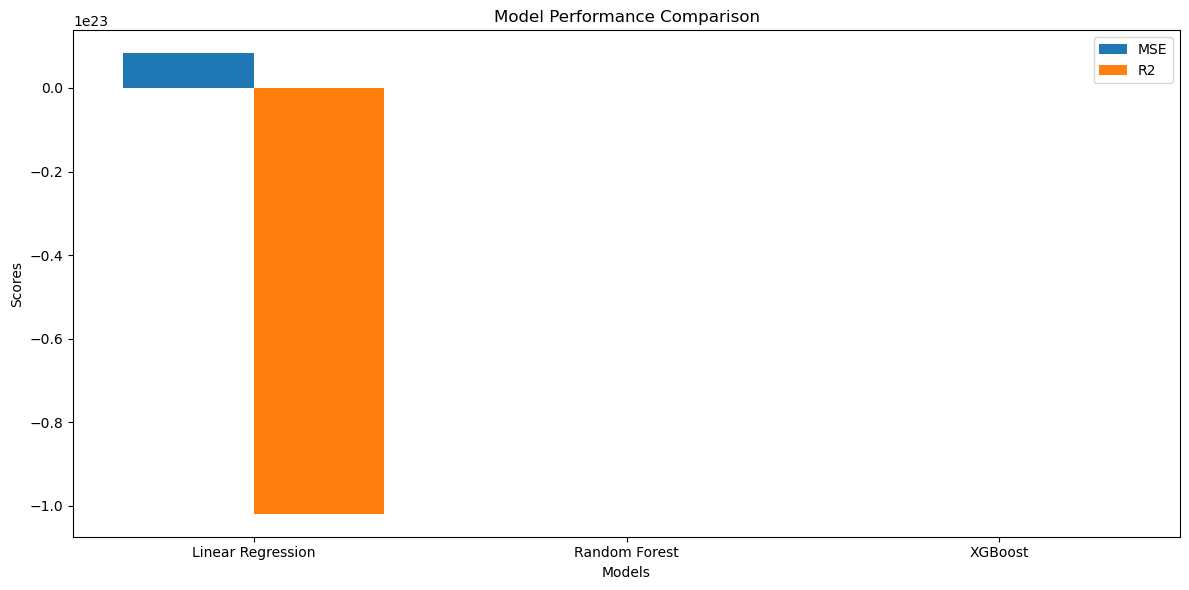

In [7]:
#bar plot of model performance metrics
models = ['Linear Regression', 'Random Forest', 'XGBoost']
mse_scores = [lr_mse, rf_mse, xgb_mse]
r2_scores = [lr_r2, rf_r2, xgb_r2]

plt.figure(figsize=(12, 6))

x = np.arange(len(models))
width = 0.35

plt.bar(x - width/2, mse_scores, width, label='MSE')
plt.bar(x + width/2, r2_scores, width, label='R2')

plt.xlabel('Models')
plt.ylabel('Scores')
plt.title('Model Performance Comparison')
plt.xticks(x, models)
plt.legend()

plt.tight_layout()
plt.show()

These are bar plots that show the importance of different features in Random Forest and XGBoost.

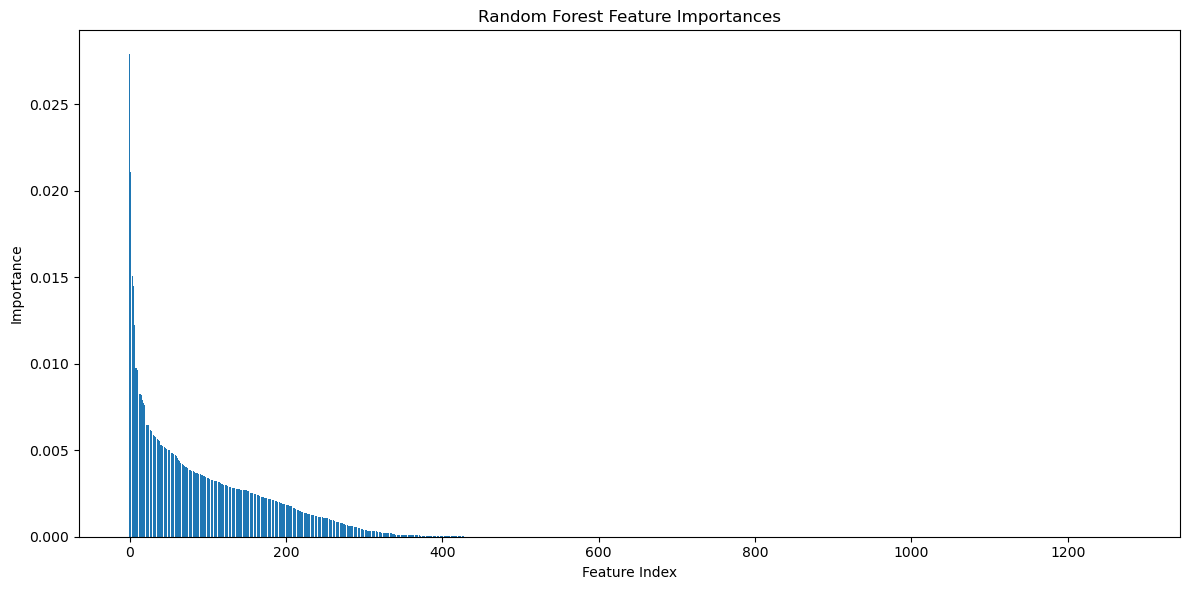

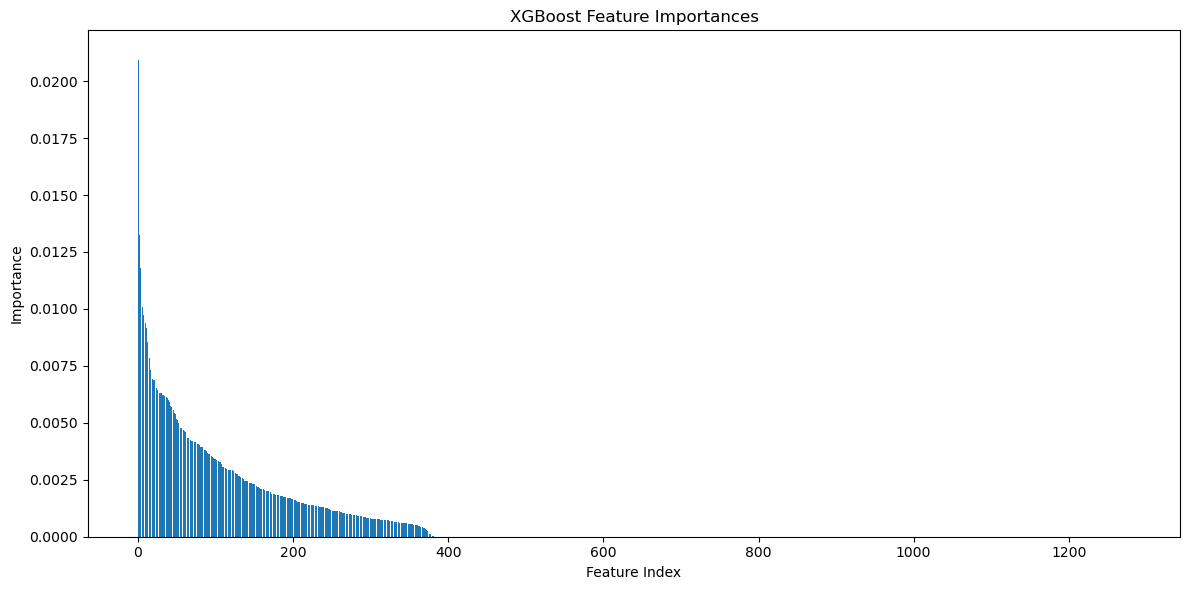

In [8]:
#feature importance plots
#random forest
rf_importances = rf_model.feature_importances_
rf_indices = np.argsort(rf_importances)[::-1]

plt.figure(figsize=(12, 6))
plt.title("Random Forest Feature Importances")
plt.bar(range(X_train.shape[1]), rf_importances[rf_indices])
plt.xlabel("Feature Index")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

#XGBoost
xgb_importances = xgb_model.feature_importances_
xgb_indices = np.argsort(xgb_importances)[::-1]

plt.figure(figsize=(12, 6))
plt.title("XGBoost Feature Importances")
plt.bar(range(X_train.shape[1]), xgb_importances[xgb_indices])
plt.xlabel("Feature Index")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()